# İlk Tekrarlayan Sinir Ağınız (RNN)

🙌 RNN'lere hoş geldiniz! Önceki derste görseller (uzamsal veri) ile ilgilenmek için CNN'leri kullandıktan sonra, şimdi zamanla ilgili veriler (***zamansal veri***) ile ilgileneceksiniz.

🎯 Bu ısınma challenge'ının hedefleri:

1. Zamansal verinin ne olduğunu anlamak
2. İlk Tekrarlayan Sinir Ağlarınızı oluşturmak



_Not: Google Colab kullanmaya gerek yok ❌_

## (1) 📚 Veri seti

_Uyarı: bu bölümde kendiniz kod yazmanıza gerek yok, dikkatli okuyun ve hücreleri çalıştırın. RNN ve LSTM modellerine odaklanmanızı istiyoruz, Python sorularına değil_ 😉

🔢 Bir şirketteki çalışanlar hakkında bazı verilere erişimimiz olduğunu düşünün.

In [4]:
import numpy as np

X = np.load('X.npy')
y = np.load('y.npy')

In [5]:
X.shape, y.shape

((25000, 10, 3), (25000,))

☝️ Veri seti **25.000 çalışanın istihdam durumunun yıllar içindeki gelişimini** tanımlar: her sekans 10 ardışık yıla karşılık gelir ve her yıl 3 bileşenden oluşan bir iş durumunu açıklar
- maaş,
- sorumluluğundaki kişi sayısı,
- şirketin büyüklüğü.

🕵🏻 Veri setini biraz daha iyi anlamak için ilk çalışanın verilerine bakalım.

In [6]:
import pandas as pd

employee_0 = pd.DataFrame(X[0],
                          columns=['salary',
                                   'responsibility',
                                   'company_size'])
round(employee_0,2)

,salary,responsibility,company_size
0,0.80,10.73,102.0
1,0.50,10.73,102.0
2,0.60,10.73,102.0
3,0.71,10.73,130.0
4,0.94,10.73,130.0
5,1.05,10.73,130.0
6,1.12,32.00,108.0
7,4.87,32.00,108.0
8,4.97,33.00,108.0
9,5.20,39.00,108.0


🎯 Bu challenge'ın amacı, geçmiş gözlemlere dayanarak bu 25.000 çalışanın her biri için 11. yıldaki aylık maaşı tahmin etmektir.

In [7]:
# For example, the first employee earns 6.499 k USD per month
# during the 11th year at the company
y[0]

6.499

📈 Maaşların, sorumluluklarındaki kişi sayısının ve şirket büyüklüğünün yıllar içindeki gelişimini daha iyi anlamanız için aşağıdaki hücreyi çalıştırabilirsiniz. Bu üç değişken arasında görsel olarak bazı korelasyonlar tespit edebiliyor musunuz?

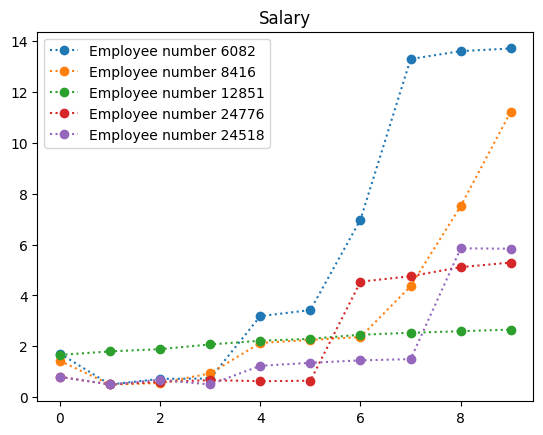

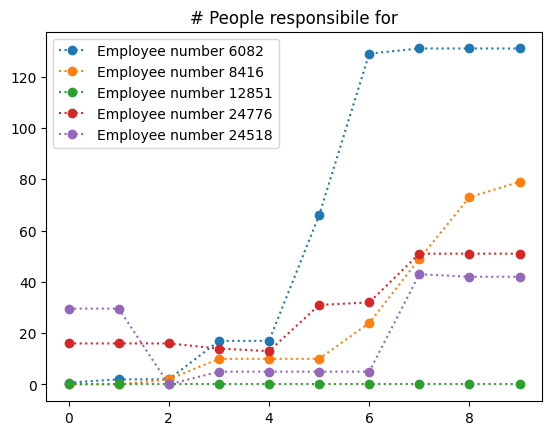

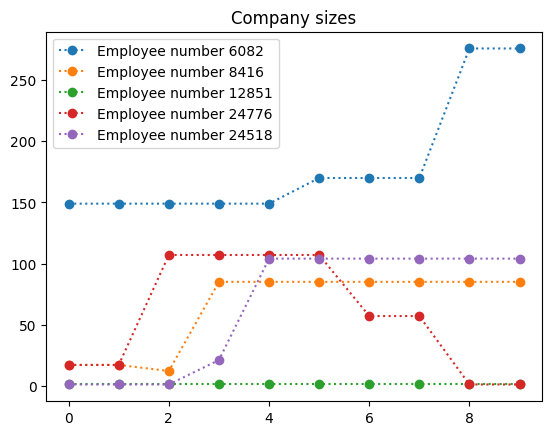

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

number_of_employees = len(X)

### Choosing random employees
##### As the employees are selected randomly, feel free to re-run this cell a few times !

number_of_randomly_selected_employees = 5

random_selection = np.random.randint(0,
                                     number_of_employees,
                                     number_of_randomly_selected_employees)


### Plotting data for the selected employees

plt.title('Salary')
for r in random_selection:
    plt.plot(X[r, :, 0],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('# People responsibile for')
for r in random_selection:
    plt.plot(X[r, :, 1],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('Company sizes')
for r in random_selection:
    plt.plot(X[r, :, 2],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

🕵🏻 **Veri Keşfi** 🕵🏻 Gözlemlerin değişkenliğini daha iyi anlamak için şunların dağılımına bakın:
* 10. yıldaki tüm maaşlar,
* sorumluluğundaki kişiler,
* ve şirket büyüklükleri

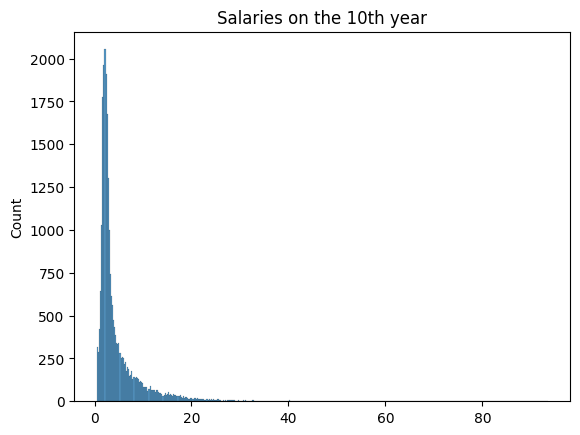

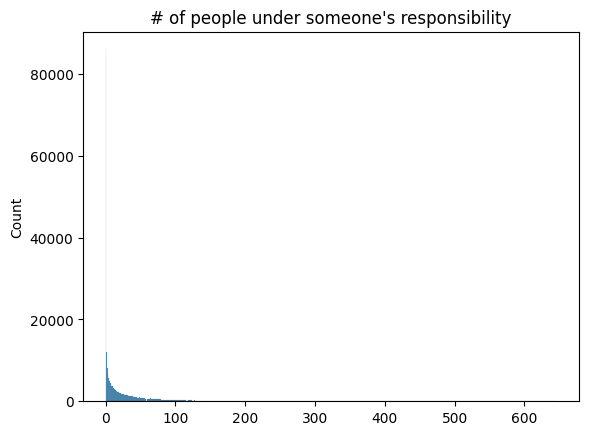

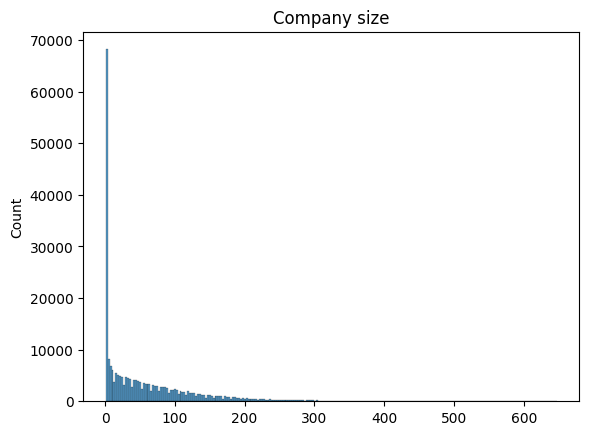

In [9]:
import seaborn as sns

plt.title("Salaries on the 10th year")
sns.histplot(X[:, -1, 0].flatten()) # all the employees, last year, feature #0 = salaries
plt.show()

plt.title("# of people under someone's responsibility")
sns.histplot(X[:, :, 1].flatten()) # all the employees, all the years, feature #1 = responsabilities
plt.show()

plt.title("Company size")
sns.histplot(X[:, :, 2].flatten()) # all the employees, all the years, feature #2 = company size
plt.show()

✂️ **Tutma yöntemi** Veri setini eğitim ve test setine ayıralım (80/20)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Notice that we are train_test_splitting the 25 000 employees!

## (2) 💻 Basit bir RNN

🤗 Artık bu şirketin veri setiyle tanıştığınıza göre, ilk Tekrarlayan Sinir Ağınızı oluşturacaksınız. Basit bir mimariyle başlayalım.

❓ **Soru** ❓ Şunları içeren bir model yazın:
- Eğitim setine uyarlanmış bir ***Normalization*** katmanı
- 20 *ünite* içeren bir ***SimpleRNN*** katmanı (Tekrarlayan Katman için aktivasyon fonksiyonu olarak `tanh`'ın daha uygun olduğunu unutmayın)
- 10 nöronlu bir ***Dense*** katmanı
- Görevinize özel bir ***Dense*** katmanı (= maaş ***tahmini*** yapmak için)

👩🏻‍🏫 Unutmayın: İlk katmandan önce `keras.Input` eklemeyi unutmayın.

In [11]:
from keras import Sequential, Input
from keras.layers import Dense, SimpleRNN, Flatten, Normalization

In [12]:
X_train.shape[1:]

(10, 3)

In [ ]:
# YOUR CODE HERE
normalizer = Normalization()
normalizer.adapt(X_train)

model = Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(normalizer)

model.add(SimpleRNN(units=20, activation='tanh'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation="linear"));
    

❓ **Soru**: RNN'inizde kaç tane eğitilebilir parametre var ❓

In [14]:
# YOUR CODE HERE
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 10, 3)          │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 20)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708 (2.77 KB)

 Trainable params: 701 (2.74 KB)

 Non-trainable params: 7 (32.00 B)

❓ **Soru** ❓ Parametre sayısını elle yeniden hesaplamaya çalışın.


> CEVABINIZI BURAYA YAZIN

<details>
    <summary><i>Cevap</i></summary>


- <u> Normalizasyon Katmanı</u>: 
    - Bu katman normalize edilecek $\color{red}{n_x = 3} $ özelliğe (maaş, sorumluluk, şirket büyüklüğü) sahiptir. Her biri için <font color=blue>_ortalama_</font> ve <font color=blue>_standart_sapma_</font> hesaplanması gerekir. Yani $\color{red}{n_x = 3} \times \color{blue}{2} = 6$ eğitilemez parametremiz vardır. 7. parametre başlangıçta 0'a ayarlanmış bir bias'tır.

- <u> Tekrarlayan Katman</u>: 
    - Eğer $\color{green}{n_h = 20} $ RNN ünitesi $\color{red}{n_x = 3} $ özelliğe paralel uygulanırsa, Tekrarlayan Katman $\color{green}{n_h}(\color{green}{n_h} + \color{red}{n_x} + 1) = \color{green}{20} \times (\color{green}{20}+\color{red}{3}+1) = \color{green}{20} \times 24 = 480$ eğitilebilir parametreye sahiptir.
    - Bu sayının her sekansın uzunluğundan (burada 10 gün) *bağımsız* olduğuna dikkat edin
    
- <u> Yoğun Katman</u>: 
    - $\color{green}{n_h = 20} $ RNN ünitesi ve $1$ bias ile başlayarak, 10 nöron kullanarak, Yoğun Katman $ (\color{green}{20}+1) \times 10 = 21 \times 10 = 210$ parametreye sahiptir
    
- <u> Tahmin Yoğun Katmanı</u>: 
    - $10$ nöron ve $1$ bias ile başlayarak, 11. maaşı tahmin etmek için 1 nöron kullanarak, Tahmin Yoğun Katmanı $ (10+1) \times 1 = 11 \times 1 = 11$ parametreye sahiptir
    
</details>    

❓ **Soru** ❓ Modelinizi derleyin. RNN için ***rmsprop*** optimizer'ını (*adam* yerine) kullanmanızı öneriyoruz.

In [15]:
# YOUR CODE HERE
# opti rmsprop, loss mse ekleme
def compile_model(model):
    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['mae'])
    return model

model = compile_model(model)

❓ **Sorular** ❓ 

* Modelinizi eğitim veri setinizde eğitin:
    * %20'lik bir Doğrulama Bölümü kullanın
    * ve sabır $= 5 $ olan bir Erken Durdurma Kriteri kullanın
* Test setindeki performansınızı değerlendirin

In [18]:
# YOUR CODE HERE
import time
start = time.time()

from keras.callbacks import EarlyStopping
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    batch_size=32,
                    epochs=100,
                    callbacks=[es],
                    verbose=1)
end = time.time()
print(f"gecen sure {end}")

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 25.3824 - mae: 2.2767 - val_loss: 7.0570 - val_mae: 0.8490
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 4.3923 - mae: 0.6040 - val_loss: 2.2078 - val_mae: 0.4359
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 2.0499 - mae: 0.4196 - val_loss: 1.3574 - val_mae: 0.3877
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 1.4834 - mae: 0.3839 - val_loss: 1.0632 - val_mae: 0.3907
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 1.1872 - mae: 0.3615 - val_loss: 0.8388 - val_mae: 0.3091
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step - loss: 1.0151 - mae: 0.3522 - val_loss: 0.7562 - val_mae: 0.2873
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - loss: 0.9157 - mae: 0.3478 - val_loss: 0.7074 - val_mae: 0.2919
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - loss: 0.8494 - mae: 0.3379 - val_loss: 0.8334 - val_mae: 0.4411
Epoch 9/100
500/500 ━━━━━━━━━━━━━

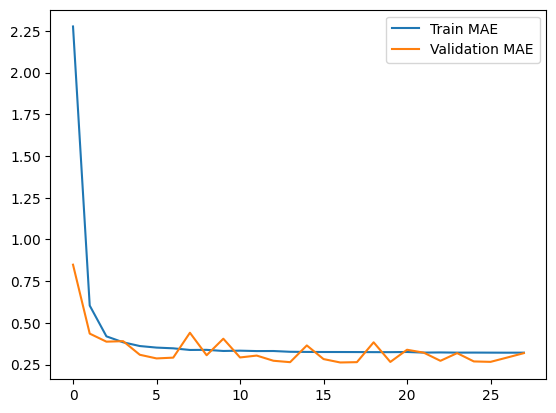

In [19]:
plt.plot(history.history["mae"], label = "Train MAE")
plt.plot(history.history["val_mae"], label = "Validation MAE")
plt.legend()

## (3) 💻 Temel karşılaştırma

> ❗️ **Önemli hatırlatma** ❗️ 
>  
> ***Derin Öğrenme modellerinizi ve daha genel olarak herhangi bir Makine Öğrenmesi modelini her zaman bir temel modelle karşılaştırmayı unutmayın.***

🧑🏻‍🏫 Amacımızın çalışanların 11. yıl için maaşını tahmin etmek olduğunu unutmayın. Bu bir ***Regresyon görevidir***. Hangi temel modeli oluşturabiliriz?
1. Geleneksel regresyon modeli durumunda, `y_test` için temel tahmin **`y_train`'in ortalamasını tahmin etmektir**... ancak bu seçenek zamanla ilgili seriler için alakasız olabilir. Teorik olarak, birinin maaşının yıllar içinde artması gerekir!
2. Regresyon görevi için alternatif temel tahmin **son görülen değeri tahmin etmektir**

❓ **Sorular** ❓ 
* 10. ve 11. yıl arasında maaşın sabit kaldığını tahmin eden temel modelin Ortalama Mutlak Hatasını hesaplayın
* Bu temel modeli RNN'inizle karşılaştırın

In [20]:
# YOUR CODE HERE
model_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Model Ortalama Mutlak Hatası {model_mae[1]}")

Model Ortalama Mutlak Hatası 0.2883484959602356


In [21]:
y_test_baseline = X_test[:, -1, 0]
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))

print(f'Temel Model MAE = {mae_baseline:.3f}')
print("karşısında")
print(f'RNN MAE = {model_mae[1]:.3f}')

Temel Model MAE = 0.617
karşısında
RNN MAE = 0.288


👉 Bu soruda takılırsanız, `(4) LSTM`'i deneyin ve sonra buraya geri dönün.

🧑🏻‍🏫 Gerekirse TA'ya sorun. Cevaba sadece bu soruları başarısızlıkla cevaplamaya çalıştıktan sonra bakın.

<details>
    <summary><i>Cevap</i></summary>


```python
# Bir sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0] 
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))   
```
    
</details>    

😁 RNN'inizin temel modelden biraz daha iyi performans gösterdiğini fark etmelisiniz.

## (4) 💻 LSTM: Uzun-Kısa Süreli Bellek

❓ **Sorular** ❓ 

* Aynı modeli yazın, ancak `SimpleRNN` katmanı yerine `LSTM` katmanı ile
* Test setindeki performansınızı değerlendirin

In [29]:
# YOUR CODE HERE

from keras.layers import LSTM
from keras.callbacks import EarlyStopping

model_lstm = Sequential()
model_lstm.add(normalizer)
model_lstm.add(LSTM(units=20, activation='tanh'))
model_lstm.add(Dense(10, activation='relu'))
model_lstm.add(Dense(1, activation='linear'))

model_lstm = compile_model(model_lstm)

es = EarlyStopping(patience=5, restore_best_weights=True)

history_lstm = model_lstm.fit(X_train, y_train,
                              validation_split=0.2,
                              batch_size=32,
                              epochs=100,
                              callbacks=[es],verbose=1)


Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0717 - mae: 1.6222 - val_loss: 3.5297 - val_mae: 0.7599
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.1793 - mae: 0.5211 - val_loss: 1.0788 - val_mae: 0.3399
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 1.0955 - mae: 0.3445 - val_loss: 0.8545 - val_mae: 0.3724
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss: 0.8597 - mae: 0.3210 - val_loss: 0.7202 - val_mae: 0.2940
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0.7340 - mae: 0.3132 - val_loss: 0.6921 - val_mae: 0.3122
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6914 - mae: 0.3036 - val_loss: 0.6067 - val_mae: 0.2736
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6602 - mae: 0.3003 - val_loss: 0.5857 - val_mae: 0.2541
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6361 - mae: 0.2961 - val_loss: 0.5818 - val_mae: 0.2700
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 

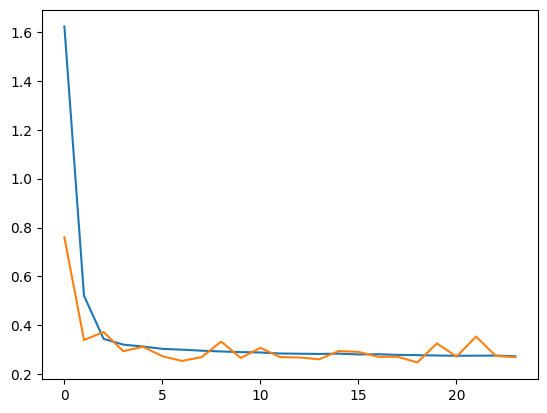

In [30]:
plt.plot(history_lstm.history["mae"])
plt.plot(history_lstm.history["val_mae"])

In [31]:
lstm_mae = model_lstm.evaluate(X_test, y_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7755 - mae: 0.2685


In [32]:
print(f'Temel Model MAE = {mae_baseline:.3f}')
print("karşısında")
print(f'RNN MAE = {model_mae[1]:.3f}')
print("karşısında")
print(f'LSTM MAE = {lstm_mae[1]:.3f}')

Temel Model MAE = 0.617
karşısında
RNN MAE = 0.288
karşısında
LSTM MAE = 0.268


💪 LSTM, daha düşük MAE ile SimpleRNN'den biraz daha iyi performans göstermelidir.

🏁 Tebrikler! Sıralı veriler üzerinde RNN eğitmeyi öğrendiniz.
 

💾 Notebook'unuzu git add/commit/push yapmayı unutmayın...

🚀 ... ve sonraki challenge'a geçin!

---

<u>Not</u>: Üzerinde çalıştığınız sekanslar tamamen sahte. Benzer verileri eğitmeniz ve üretmeniz gerektiğinde, böyle bir veri setini simüle etmek için kullanılan fonksiyonları aşağıda bulabilirsiniz.

## 🛠 (Yardımcı Araçlar)

In [33]:
def create_sequences(number):
    X, y = [], []

    for i in range(number):
        x_i, y_i = create_individual_sequence(10)
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

def create_individual_sequence(length):
    company_sizes = []
    nb_persons = []
    salaries = []


    # Education level
    educ_level = [max(0, int(np.random.normal(10, 2)))]*length

    # Company size
    current_size = int(1 + np.random.beta(.4, 4)*500)
    for i in range(length):
        if not np.random.randint(4): # Change 1 out of 3 possibilities
            current_size = int(max(1, np.random.normal(current_size, 50)))
        company_sizes.append(current_size)

    # Number of persons
    nb_iter = np.random.beta(.15, 4)*300
    for i in range(length):
        if not np.random.randint(2): # Change 1 out of 2 possibilities
            R_1 = np.random.beta(0.5, 8)*3
            nb_iter = nb_iter + max(-2, R_1*company_sizes[i] + np.random.randint(-2, 2))
            nb_iter = max(0, nb_iter)
            nb_iter = int(min(company_sizes[i]-1, nb_iter))
        nb_persons.append(nb_iter)


    # Salary
    salary_iter = max(800, int(np.random.normal(1200, 300)+ 0.05*company_sizes[0] +  np.random.normal(40, 400)))
    salaries.append(salary_iter)
    for i in range(1, length + 1):
        R_1 = np.random.normal(100, 50)
        change_person = nb_persons[i-1] - nb_persons[i-2]
        change_company = max(0, company_sizes[i-1] - company_sizes[i-2])
        salary_iter = salary_iter + 0.05*change_company + change_person*R_1 + np.random.normal(100, 50)
        salary_iter = max(int(salary_iter), 500)

        salaries.append(salary_iter)

    y = salaries[-1]/1000
    salaries = [_/1000 for _ in salaries[:-1]]

    return np.array([salaries, nb_persons, company_sizes]).T, y

In [34]:
X, y = create_sequences(25000)

np.save('X', X.astype(np.float32))
np.save('y', y)